# Word2Vec Embedding Evaluation
This is a very simple notebook that simplifies the testing of the trained model. It loads the embeddings and vocabularynd runs a few simple qualitative checks

In [23]:
from pathlib import Path
import sys
import numpy as np
from IPython.display import Image, display

In [9]:

# Ensure project src/ is on path when running the notebook
PROJECT_ROOT = Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))


# allow autoreloading of modules when they are edited outside the notebook
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
run_name = "test0" 

run_dir = Path("output") / run_name


In [ ]:
from src.model.word2vec import MyWord2Vec

emb_path = run_dir / f"embeddings_{run_name}.npz"

if not emb_path.exists():
    raise FileNotFoundError(f"Embedding file not found: {emb_path}")

model = MyWord2Vec.load(str(emb_path))
print(f"Loaded embeddings from {emb_path}")
print(f"Vocab size: {len(model.vocab)}, embedding dim: {model.embed_dim}")

Loaded embeddings from output/test0/embeddings_test0.npz
Vocab size: 13966, embedding dim: 100


Final recorded loss: 2.7238


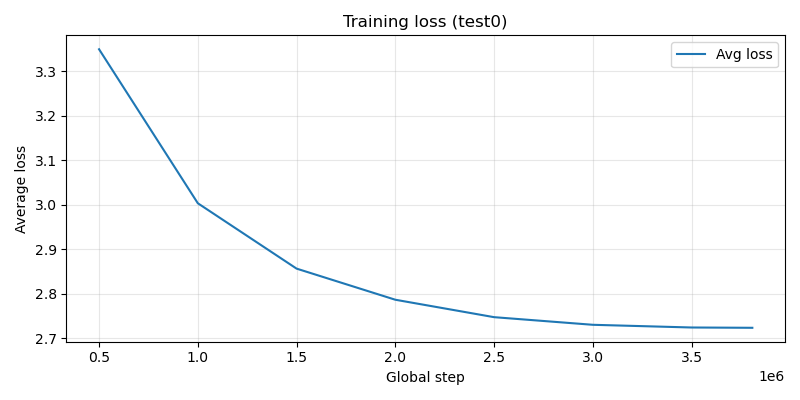

In [ ]:
loss_npz = run_dir / f"loss_{run_name}.npz"
loss_png = run_dir / f"loss_{run_name}.png"

if loss_npz.exists():
    data = np.load(loss_npz)
    steps = data.get("steps")
    losses = data.get("losses")
    if losses is not None and len(losses) > 0:
        final_loss = float(losses[-1])
        print(f"Final recorded loss: {final_loss:.4f}")
    else:
        print("Loss file found but contains no entries.")
else:
    print(f"Loss data not found at {loss_npz}")
    steps = losses = None

# display the loss plot if it exists
if loss_png.exists(): display(Image(filename=str(loss_png)))


In [29]:
def show_similar(query: str, top_k: int = 10):
    try:
        sims = model.get_most_similar(query, top_k=top_k)
    
    except Exception as exc:
        print(f"Error for '{query}': {exc}")
        return
    
    for word, score in sims:
        print(f"{word:>15}  {score:.4f}")

In [33]:
queries = ["cat", "dog", "computer", "king", "queen", "man", "woman", "italy"]

top_k = 10

for q in queries:
    print(f"\nTop {top_k} similar words to '{q}':")
    show_similar(q, top_k=top_k)


Top 10 similar words to 'cat':
         maguey  0.9994
           benz  0.9994
      victoriae  0.9994
          hindu  0.9993
           saga  0.9993
             ba  0.9993
         monday  0.9993
       alhazred  0.9993
            var  0.9993
         viewer  0.9992

Top 10 similar words to 'dog':
          aruba  0.9996
      electoral  0.9995
        windows  0.9995
          tells  0.9995
          eddie  0.9995
          stars  0.9994
     supplement  0.9994
      mcclellan  0.9994
    observation  0.9994
       orthodox  0.9994

Top 10 similar words to 'computer':
         legend  0.9984
        program  0.9983
     azerbaijan  0.9981
         arctic  0.9981
         figure  0.9981
        playing  0.9980
        records  0.9979
     foundation  0.9979
          lunar  0.9979
      testament  0.9978

Top 10 similar words to 'king':
       director  0.9965
       minister  0.9963
           paul  0.9955
           film  0.9951
          prime  0.9949
          henry  0.9944
  